# 03 · Tempo across the repertoire: shared classes or not?

**Starting point (notebook 02).** `1+1+3` codas fall into three robust tempo classes (~0.81 / 1.05 / 1.28 s).

**Question.** Is this specific to `1+1+3`, or is tempo a shared dimension of the whole repertoire, with other coda types also showing discrete tempo classes, perhaps at the same values?

**Plan.**
1. Check a design assumption: can coda types be grouped into "same rhythm, different tempo" families?
2. Run the tempo test on every coda type, with stricter safeguards than in notebook 02.
3. Test whether tempo centres align across types.
4. Test whether tempo shifts together across types within a recording session.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, cross_val_score
from whalecodas import load_codas, filter_codas, rhythm_matrix, add_session, tempo_scan
from whalecodas.data import PROJECT_ROOT
FIG = PROJECT_ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 200)

df = add_session(filter_codas(load_codas()))
print(f"{len(df)} codas, {df.CodaType.nunique()} types, {df.session.nunique()} sessions (unit × day)")

7268 codas, 24 types, 103 sessions (unit × day)


## 1. Are rhythm and tempo independent?

Several expert types look like the same rhythm at different speeds (`5R1/5R2/5R3`, `4R1/4R2`, `8i/8R`…). If so, they should be grouped into rhythm families before looking for tempo classes. Test it: for each pair of types with the same click count, train a classifier that sees **only rhythm** (normalised ICIs, no duration). If two types share a rhythm, it should perform near chance (0.5).

In [2]:
R = rhythm_matrix(df)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = []
for n in sorted(df.nClicks.unique()):
    types = [t for t, c in df[df.nClicks == n].CodaType.value_counts().items() if c >= 10]
    for a, b in itertools.combinations(types, 2):
        m = df.CodaType.isin([a, b]).to_numpy()
        y = df.CodaType.to_numpy()[m] == a
        clf = LogisticRegression(class_weight="balanced", max_iter=2000, C=10)
        acc_r = cross_val_score(clf, R[m, : n - 1], y, cv=cv, scoring="balanced_accuracy").mean()
        acc_t = cross_val_score(LogisticRegression(class_weight="balanced"), np.log(df.Duration.to_numpy()[m])[:, None], y, cv=cv, scoring="balanced_accuracy").mean()
        rows.append({"clicks": n, "pair": f"{a} vs {b}", "rhythm only": acc_r, "tempo only": acc_t})
pairs = pd.DataFrame(rows).sort_values("rhythm only").round(2)
pairs.head(10)

,clicks,pair,rhythm only,tempo only
19,5,5R2 vs 5R3,0.70,1.00
2,4,4R2 vs 4R1,0.78,1.00
17,5,5R1 vs 5R3,0.79,1.00
7,4,4D vs 1+31,0.81,0.95
28,10,10i vs 10R,0.86,0.97
27,9,9i vs 9R,0.87,0.99
9,4,4R1 vs 1+31,0.88,1.00
0,3,3D vs 3R,0.88,0.98
24,8,8i vs 8R,0.90,0.98
15,5,5R1 vs 5R2,0.93,1.00


**Result.** Even the most similar-looking pairs are separable from rhythm alone well above chance (`5R2` vs `5R3`: 0.70; `4R1` vs `4R2`: 0.78). Rhythm and tempo are **not independent**: the shape of a coda changes slightly with its speed. Any threshold for merging types into families would be arbitrary.

**Decision.** Keep expert types as they are and reformulate the question: *within each type*, is there more than one tempo class? And do the centres of those classes line up across types?

## 2. Tempo scan over all coda types

For every type with ≥ 30 codas: 1-D Gaussian mixture on log(duration), k chosen by BIC. Two new safeguards compared with notebook 02:

- **Ashman's D** between adjacent components. D > 2 means genuinely separated peaks; D < 1 means several Gaussians fitting one skewed peak.
- **Session bootstrap.** Codas from the same session (same unit, same day) are not independent. Whole sessions are resampled, not individual codas. This is the key correction.

*This cell takes about a minute.*

In [3]:
scan = tempo_scan(df, n_boot=100)
top_unit = df.groupby("CodaType").Unit.agg(lambda s: s.value_counts(normalize=True).iloc[0])
scan["top unit share"] = scan["type"].map(top_unit).round(2)
min_w = {t: GaussianMixture(k, random_state=0, n_init=5).fit(np.log(df[df.CodaType == t].Duration.to_numpy())[:, None]).weights_.min()
         for t, k in zip(scan["type"], scan["k_BIC"]) if k > 1}
scan["min weight"] = scan["type"].map(min_w).round(2)

def verdict(r):
    if r.k_BIC == 1:
        return "single tempo"
    if r.min_ashman_D < 1:
        return "artefact (one skewed peak)"
    if r.min_ashman_D >= 2 and r["P(k>=2) sessions"] >= 0.9 and r["min weight"] >= 0.1:
        return "ROBUST multimodal"
    if r.min_ashman_D >= 1.5 and r["P(k>=2) sessions"] >= 0.75:
        return "candidate"
    return "not supported"

scan["verdict"] = scan.apply(verdict, axis=1)
scan

,type,nClicks,codas,sessions,k_BIC,centres_s,min_ashman_D,P(k>=2) sessions,P(k=k_BIC) sessions,top unit share,min weight,verdict
0,1+1+3,5,3574,73,3,"[0.808, 1.047, 1.276]",2.42,1.00,0.90,0.24,0.26,ROBUST multimodal
1,5R1,5,1510,75,3,"[0.326, 0.326, 0.349]",0.01,1.00,0.45,0.15,0.17,artefact (one skewed peak)
2,4R2,4,303,14,1,[0.97],NaN,0.59,0.41,0.97,NaN,single tempo
3,5R2,5,287,26,1,[0.509],NaN,0.03,0.97,0.39,NaN,single tempo
4,4D,4,219,24,2,"[0.516, 0.528]",0.53,0.69,0.46,0.95,0.45,artefact (one skewed peak)
5,6i,6,182,52,3,"[0.229, 0.397, 0.512]",1.74,0.96,0.51,0.23,0.16,candidate
6,8i,8,178,49,2,"[0.343, 0.369]",0.25,1.00,0.07,0.21,0.31,artefact (one skewed peak)
7,7D1,7,171,17,2,"[1.075, 1.299]",2.36,0.78,0.61,0.82,0.48,candidate
8,7i,7,145,50,3,"[0.206, 0.321, 0.503]",2.39,0.87,0.45,0.29,0.18,candidate
9,9i,9,135,44,3,"[0.193, 0.365, 0.673]",4.35,1.00,0.52,0.21,0.03,candidate


**Reading the table.**

- **`1+1+3` is the only type that passes every test**: separated peaks (D ≥ 2.4), all components substantial, multimodal in 100% of session resamples and k = 3 in ~90%.
- **Artefacts.** `5R1`, `4D`, `8i`, `3D` get k > 1 from BIC, but their components overlap almost completely (D < 1). The GMM is describing an asymmetric peak, not classes. Without Ashman's D these would have been false discoveries.
- **Candidates.** The `i` types (`6i`, `7i`, `9i`) and `7D1` look multimodal in most session resamples, but the *number* of classes is unstable, and some modes are tiny or come mostly from one unit (e.g. `7D1`: 82% from unit F; the fast mode of `9i` is 5 codas).
- **Single tempo.** `5R2`, `8R`, `7D2`, `10i`, `2+3`: consistent with one tempo class each. `4R2` is ambiguous (multimodal in ~60% of session resamples) and 97% of its codas come from one unit, so it says little about the clan as a whole.

## 3. The tempo "ladder" of the repertoire

Every type's duration distribution, with the three `1+1+3` classes marked. If tempo classes were shared, other types' peaks would sit on the dashed lines.

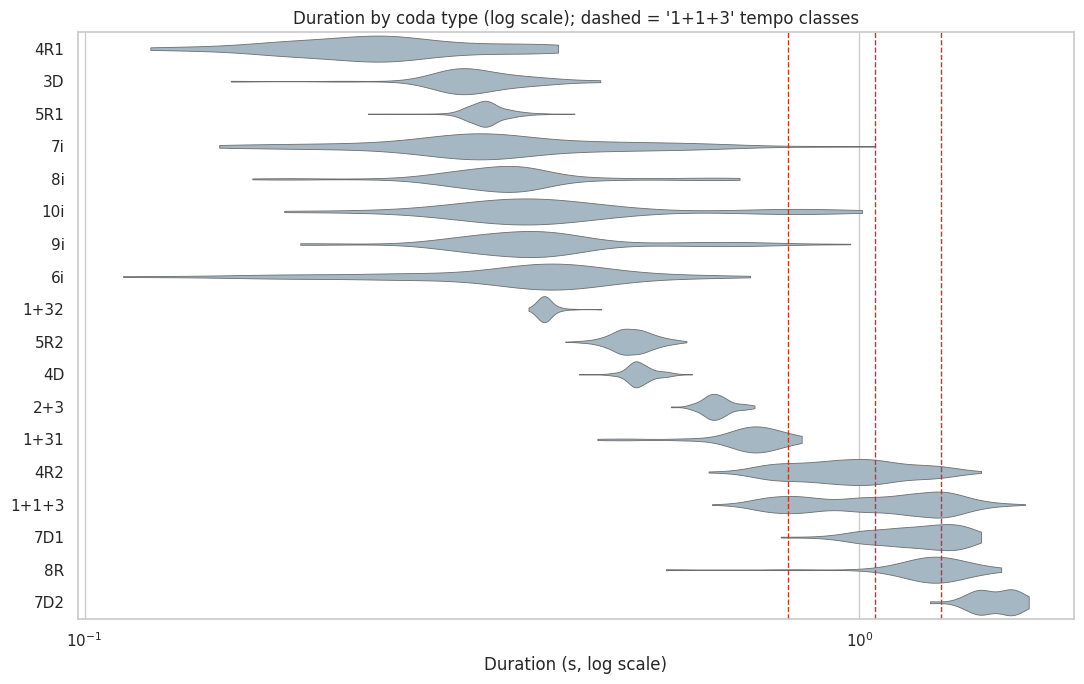

In [4]:
order = df.groupby("CodaType").Duration.median().sort_values().index
order = [t for t in order if (df.CodaType == t).sum() >= 30]
fig, ax = plt.subplots(figsize=(11, 7))
sns.violinplot(data=df[df.CodaType.isin(order)], y="CodaType", x="Duration", order=order, log_scale=True,
               inner=None, cut=0, density_norm="width", linewidth=0.6, color="#9fb8c8", ax=ax)
for c in [0.808, 1.047, 1.276]:
    ax.axvline(c, ls="--", lw=1, color="#c0392b")
ax.set(title="Duration by coda type (log scale); dashed = '1+1+3' tempo classes", xlabel="Duration (s, log scale)", ylabel="")
plt.tight_layout(); plt.savefig(FIG / "03_tempo_ladder.png", dpi=150); plt.show()

Durations spread over a whole order of magnitude (~0.15 to ~1.6 s) and many types sit between the dashed lines. At the level of the whole repertoire there is **no visible small shared grid**. With only one robust multimodal type, a formal test of alignment across the repertoire has no power, so no claim is made either way.

One pattern worth noting, not claiming: the slowest types (`8R`, the slow mode of `7D1`, the slow class of `1+1+3`) all peak around 1.2–1.3 s, across 5, 7 and 8 clicks. (The violins are smoothed, which is why `1+1+3`'s three peaks look softer here than in notebook 02.)

## 4. A specific alignment: `7D1` and `1+1+3`

`7D1` (7 clicks, decreasing rhythm) has two tempo modes at ~1.08 and ~1.30 s, close to two of the `1+1+3` classes. Compare 95% bootstrap intervals of the centres.

In [5]:
rng = np.random.default_rng(1)
def centre_ci(x, k, B=200):
    C = np.array([np.sort(np.exp(GaussianMixture(k, random_state=0, n_init=3).fit(x[rng.integers(0, len(x), len(x))]).means_.ravel())) for _ in range(B)])
    return pd.DataFrame(np.percentile(C, [2.5, 97.5], axis=0).T, columns=["CI low", "CI high"]).round(3)

for t, k in [("1+1+3", 3), ("7D1", 2)]:
    x = np.log(df[df.CodaType == t].Duration.to_numpy())[:, None]
    print(t); display(centre_ci(x, k))

1+1+3


,CI low,CI high
0,0.803,0.814
1,1.033,1.070
2,1.267,1.288


7D1


,CI low,CI high
0,1.030,1.122
1,1.264,1.344


In [6]:
d7 = df[df.CodaType == "7D1"]
print("7D1 codas by unit:", d7.Unit.value_counts().to_dict())
print("7D1 recording days:", d7.Date.dt.date.nunique(), "| unit F days:", d7[d7.Unit == "F"].Date.dt.date.nunique())
pd.crosstab(d7[d7.Unit == "F"].Date.dt.date, np.where(d7[d7.Unit == "F"].Duration > 1.19, "slow mode", "fast mode"))

7D1 codas by unit: {'F': 141, 'A': 10, 'J': 5, 'R': 5, 'U': 5, 'V': 4, 'D': 1}
7D1 recording days: 16 | unit F days: 6


col_0,fast mode,slow mode
Date,,
2005-01-23,1,0
2010-02-02,12,0
2010-02-12,22,61
2010-03-03,0,18
2010-03-04,16,10
2015-03-19,0,1


**Result.** The intervals overlap for both modes. It is an intriguing match across different rhythms and click counts. But the evidence is **weak**: 82% of `7D1` codas come from unit F, and 127 of those 141 were recorded on just 3 days. A few sessions' worth of codas carries far less independent information than the raw count suggests. The hypothesis *"tempo classes are shared across rhythm types"* stays open, and needs data from more units.

## 5. Does tempo shift together within a session?

In the table above, on days when unit F's `7D1` codas were slow, its `1+1+3` codas also tended to be slow. Hypothesis: **tempo co-varies across coda types within a session** (e.g. a whole conversation speeds up or slows down).

Test: standardise log-duration within each type (z-score), average per session, and correlate the `1+1+3` session mean with the mean of all other types in the same session. Sessions need ≥ 10 codas of each.

40 sessions | Pearson r = 0.15, p = 0.37 | permutation p = 0.36


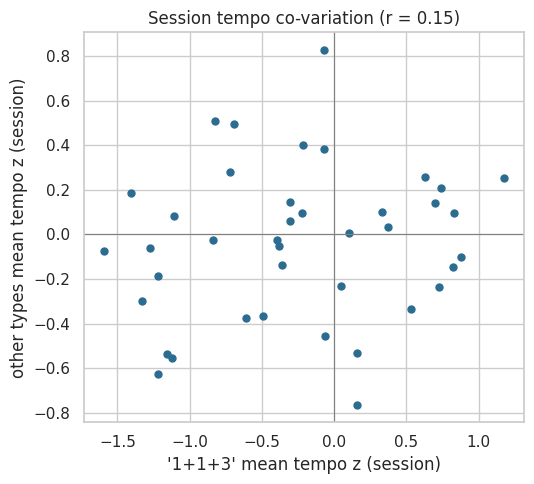

In [7]:
df["z"] = df.groupby("CodaType").Duration.transform(lambda s: (np.log(s) - np.log(s).mean()) / np.log(s).std())
S = df.assign(is113=df.CodaType == "1+1+3").groupby(["session", "is113"]).z.agg(["mean", "size"]).unstack()
S = S[(S[("size", True)] >= 10) & (S[("size", False)] >= 10)]
a, b = S[("mean", True)].to_numpy(), S[("mean", False)].to_numpy()
r, p = stats.pearsonr(a, b)
rng = np.random.default_rng(0)
p_perm = np.mean([abs(np.corrcoef(a, rng.permutation(b))[0, 1]) >= abs(r) for _ in range(10000)])
print(f"{len(S)} sessions | Pearson r = {r:.2f}, p = {p:.2f} | permutation p = {p_perm:.2f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(a, b, s=25, color="#2b6c8f")
ax.axhline(0, color="grey", lw=.8); ax.axvline(0, color="grey", lw=.8)
ax.set(xlabel="'1+1+3' mean tempo z (session)", ylabel="other types mean tempo z (session)", title=f"Session tempo co-variation (r = {r:.2f})")
plt.tight_layout(); plt.savefig(FIG / "03_session_covariation.png", dpi=150); plt.show()

**Result: not supported.** Across 40 sessions there is no meaningful correlation (r ≈ 0.15, p ≈ 0.37; the permutation test agrees). The pattern seen in unit F's `7D1` was anecdotal.

One more check, type by type (sessions with ≥ 5 codas of both types):

In [8]:
rows = []
for t in [x for x in scan["type"] if x != "1+1+3"]:
    T = df[df.CodaType.isin(["1+1+3", t])].groupby(["session", "CodaType"]).z.agg(["mean", "size"]).unstack()
    T = T[(T[("size", "1+1+3")] >= 5) & (T[("size", t)] >= 5)]
    if len(T) >= 6:
        rho, pv = stats.spearmanr(T[("mean", "1+1+3")], T[("mean", t)])
        rows.append({"type": t, "sessions": len(T), "spearman": rho, "p": pv})
pt = pd.DataFrame(rows).round(3)
print(f"{len(pt)} comparisons -> Bonferroni threshold = {0.05/len(pt):.4f}")
pt

8 comparisons -> Bonferroni threshold = 0.0063


,type,sessions,spearman,p
0,5R1,39,-0.050,0.762
1,4R2,6,0.714,0.111
2,5R2,14,-0.596,0.025
3,6i,8,0.238,0.570
4,8i,12,-0.028,0.931
5,7i,7,-0.286,0.535
6,9i,12,0.608,0.036
7,2+3,6,-0.771,0.072


A couple of types reach p < 0.05 on their own, but with **opposite signs** (one positive, one negative) and none survives the Bonferroni correction. With this many tests, one or two nominal hits are expected by chance alone. Conclusion unchanged.

## Summary: evidence table

| claim | evidence | status |
|---|---|---|
| `1+1+3` has 3 tempo classes (~0.81 / 1.05 / 1.28 s) | D ≥ 2.4; multimodal in 100% of session resamples; k = 3 in ~90% | **robust** |
| Rhythm and tempo are independent features | rhythm alone separates same-shape types at 0.70–0.93 | **rejected**: they interact |
| Apparent tempo splits in `5R1`, `4D`, `8i`, `3D` | Ashman's D < 1 | **artefacts** |
| `i` types (`6i`, `7i`, `9i`) are tempo-multimodal | multimodal in 87–100% of session resamples; k unstable; some tiny modes | **candidate** |
| `7D1` shares two tempo classes with `1+1+3` | overlapping CIs, but 82% unit F, mostly 3 days | **weak, confounded** |
| A small tempo grid is shared by the whole repertoire | only one robust multimodal type | **not testable here** |
| Tempo co-varies across types within a session | r ≈ 0.15, p ≈ 0.37 (40 sessions) | **not supported** |

## Methodological lessons

1. **BIC alone over-splits.** It happily fits several Gaussians to a single asymmetric peak. A separation check (Ashman's D) is needed.
2. **The unit of independence is the session, not the coda.** Coda-level bootstraps overstated certainty; session-level ones are the honest measure.
3. **Negative results are results.** Two plausible hypotheses were tested and not supported, and both are reported.

## Next steps

1. **Rhythm–tempo interaction.** Model rhythm as a function of tempo (does the shape stretch uniformly when a coda slows down, or do some ICIs change more than others?). This connects to what Sharma et al. call rubato.
2. **Unit-level tempo preferences** for `1+1+3`, using sessions as the unit (e.g. mixed-effects or session-level permutation tests).
3. **Out-of-sample**: repeat the tempo scan on EC2.